# Solar + Industrial Heat Battery — EU Pulp & Paper: Results Analysis

**Run date:** 2026-07-06 · **Scenario:** fossil *steam* replacement scope, TES (heat battery) storage, 2025 costs.
**Demand basis:** SEC updated 2026-07-06 to match README — virgin pulp 3.3 MWh_th/t (NRCan, was 4.0),
Tissue 2.6 (BREF 2.0–3.3 midpoint, was 1.5), Integrated 5.0, Paper/Board 1.3.

> **Correction (2026-07-05):** an earlier run of this analysis had a units bug — the TES discount
> rate was stored as `7` (percent) in `input_heat_battery_cost.csv` but read as a fraction (700%),
> inflating the annualized storage cost ~66× and producing LCOH ≈ \$1,150–3,000/MWh. The CSV now
> stores `0.07` and the solver normalizes percent-style values. All results below use the corrected
> cost. **Fossil benchmark for comparison:** gas-boiler LCOH ≈ €43–100/MWh_th (~\$45–110)
> per Agora Industry / Fraunhofer ISI (2025), *The business case for electrifying industrial heat*
> (see `References/`).

This notebook analyzes the output of `run_ihb_potential.py --no-resume` and documents how the
numbers were produced, so results can be audited.

## How the pipeline works

1. **Site list** — `outputs/eu_pulp_paper_ihb_site_assessment_2024.csv`: one row per facility
   (Climate TRACE), with heat demand = `annual_output_t × SEC × fossil_share × replace_frac`,
   land availability within ~5 km (GEE land cover), and PVGIS solar metadata.
2. **Filters** — keep sites with `has_replaceable_heat` and `has_solar_data` (65 of 86 sites).
3. **Per-site optimization** (`flatblock_optimization/solvers/optimize_flatblock_highs_heat_battery.py`,
   HiGHS LP): minimize LCOH of **solar + thermal storage** serving a **flat load**
   = `replaceable_heat_mwh_th / 8760`, hourly over one solar year (2023).
   Decision variables: solar MW, TES charge MW, discharge MW, energy MWh, hourly dispatch, unserved.
4. **Outputs** — one CSV per site in `flatblock_optimization/output/sites/`, merged into `summary.csv`.

## Key assumptions of this run

| Parameter | Value | Where |
|---|---|---|
| Scope | Fossil **steam** only; lime-kiln fuel excluded by scope statement (not modeled) | README / CONFIG |
| Process temp (T_min) | Pulp 175 °C; Integrated / Paper/Board / Tissue 180 °C | `steam_temp_by_classification` |
| TES tank ceiling (T_max) | 1500 °C → usable stored-energy fraction ≈ 1 − T_min/T_max ≈ 0.88 | CONFIG |
| TES CAPEX | **$100/kWh (2025)** — falls to $20 (2030), $15 (2035) in the cost file | `input_heat_battery_cost.csv` |
| TES round-trip eff. | 0.97 (electric→heat 0.98 for ≤200 °C applied on charge) | CONFIG |
| Max storage duration | 12 h × discharge power | CONFIG |
| Charge/discharge ratio | P_charge ≥ 4 × P_discharge | CONFIG |
| Availability target | 90% of annual load-hours (unserved budget = 10%) | CONFIG |
| VoLL | $0/MWh (unserved is free up to the 10% budget) | CONFIG |
| Land density | 100 MW solar per km² — used only as a **flag**, not a constraint | CONFIG |
| Solar year | 2023 PVGIS hourly, single year | CONFIG |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

summary = pd.read_csv("../flatblock_optimization/output/summary.csv")
print(f"{len(summary)} site rows")
summary["status"].value_counts()

65 site rows


status
completed          60
skipped_no_load     5
Name: count, dtype: int64

## 1. Run health

Every row should be `completed`, and every row should carry `steam_temp_c` (a column added in the
steam-scope revision) — a row without it would be a **stale file from an earlier run** leaking into
the summary (see loophole L1 below).

In [2]:
ok = summary[summary["status"] == "completed"].copy()
stale = summary["steam_temp_c"].isna().sum() if "steam_temp_c" in summary else len(summary)
print(f"completed: {len(ok)} / {len(summary)}   |   rows missing steam_temp_c (stale?): {stale}")
# confirm the temperature scope actually applied
ok.groupby("classification")[["steam_temp_c", "TES_temp_min_C", "TES_usable_energy_fraction_linear",
                              "TES_electric_to_heat_efficiency"]].agg(["min", "max"])

completed: 60 / 65   |   rows missing steam_temp_c (stale?): 0


steam_temp_c        TES_temp_min_C        TES_usable_energy_fraction_linear           TES_electric_to_heat_efficiency      
                        min    max            min    max                               min       max                             min   max
classification                                                                                                                            
Integrated            180.0  180.0          180.0  180.0                          0.880000  0.880000                            0.98  0.98
Paper/Board           180.0  180.0          180.0  180.0                          0.880000  0.880000                            0.98  0.98
Pulp                  175.0  175.0          175.0  175.0                          0.883333  0.883333                            0.98  0.98
Tissue                180.0  180.0          180.0  180.0                          0.880000  0.880000                            0.98  0.98

## 2. Headline results — cost of delivered heat

`LCOE_total_$perMWh` is the levelized cost per MWh of **thermal** load served
(solar CAPEX+FOM, annualized TES CAPEX+OPEX, divided by annual load; unserved energy carries no
cost because VoLL = 0).

In [3]:
cost_cols = ["LCOE_total_$perMWh", "LCOE_solar_$perMWh", "LCOE_TES_$perMWh"]
print(ok[cost_cols].describe().round(1))
tes_share = (ok["LCOE_TES_$perMWh"] / ok["LCOE_total_$perMWh"])
print(f"\nTES share of total LCOH: median {tes_share.median():.0%} (range {tes_share.min():.0%}–{tes_share.max():.0%})")

       LCOE_total_$perMWh  LCOE_solar_$perMWh  LCOE_TES_$perMWh
count                60.0                60.0              60.0
mean                199.9               144.4              55.5
std                 175.3               138.1              39.0
min                  48.1                26.5              19.8
25%                  83.9                55.2              28.7
50%                 123.7                80.0              40.4
75%                 252.5               192.0              73.6
max                 709.3               545.9             163.4

TES share of total LCOH: median 33% (range 11%–45%)


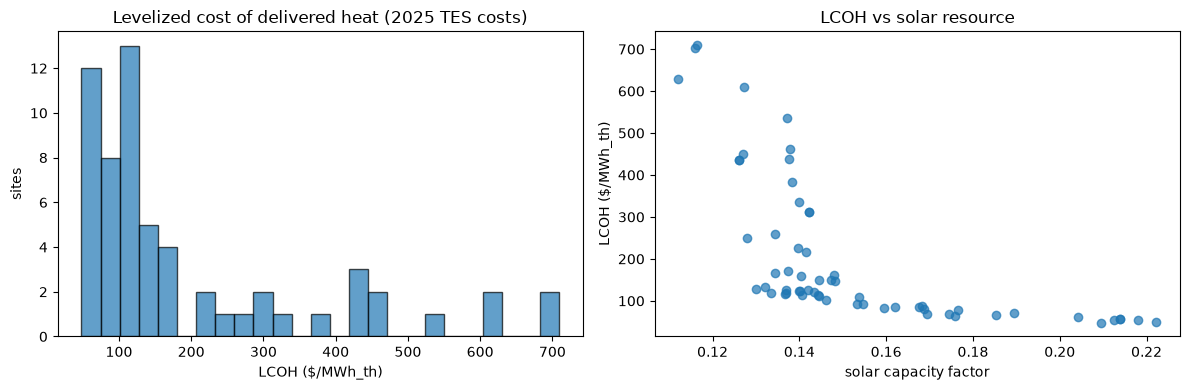

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ok["LCOE_total_$perMWh"], bins=25, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("LCOH ($/MWh_th)"); axes[0].set_ylabel("sites")
axes[0].set_title("Levelized cost of delivered heat (2025 TES costs)")
axes[1].scatter(ok["solar_capacity_factor"], ok["LCOE_total_$perMWh"], alpha=0.7)
axes[1].set_xlabel("solar capacity factor"); axes[1].set_ylabel("LCOH ($/MWh_th)")
axes[1].set_title("LCOH vs solar resource")
plt.tight_layout(); plt.show()

In [5]:
by_class = ok.groupby("classification").agg(
    sites=("source_id", "count"),
    steam_heat_GWh=("replaceable_heat_mwh_th", lambda s: s.sum() / 1e3),
    median_LCOH=("LCOE_total_$perMWh", "median"),
    median_solar_MW=("S_opt_MW", "median"),
    median_TES_MWh=("Heat_TES_energy_MWh", "median"),
).round(1)
by_class

,sites,steam_heat_GWh,median_LCOH,median_solar_MW,median_TES_MWh
classification,,,,,
Integrated,19,7275.8,132.6,247.3,684.6
Paper/Board,18,2313.7,123.7,172.2,327.7
Pulp,20,3307.5,119.0,141.2,230.4
Tissue,3,1723.9,450.9,3241.7,6919.5


In [6]:
by_country = ok.groupby("iso3_country").agg(
    sites=("source_id", "count"),
    steam_heat_GWh=("replaceable_heat_mwh_th", lambda s: s.sum() / 1e3),
    median_LCOH=("LCOE_total_$perMWh", "median"),
    median_solar_cf=("solar_capacity_factor", "median"),
).sort_values("median_LCOH").round(2)
by_country

,sites,steam_heat_GWh,median_LCOH,median_solar_cf
iso3_country,,,,
PRT,6,1056.45,55.79,0.21
FRA,5,432.84,67.89,0.17
ESP,3,1709.40,69.61,0.19
BGR,1,62.27,78.75,0.18
HRV,2,7.96,83.77,0.17
SVN,1,141.09,84.32,0.16
HUN,1,14.17,87.37,0.17
AUT,2,648.29,92.34,0.15
SVK,2,135.17,115.55,0.14


## 3. Land feasibility — is there enough solar at the site?

The LP does **not** constrain solar by land; `exceeds_land_limit` is a post-hoc flag comparing the
optimizer's solar build against `available_land_km2 × 100 MW/km²`. A site that "exceeds" is one
where the *cost-optimal* build doesn't fit — it may still be feasible with a smaller, costlier
system, which this run does not evaluate (loophole L2).

sites whose optimal solar fits available land: 35 / 60
land_ratio (optimal solar MW ÷ land-limited MW): median 0.50, max 4180.6
share of steam heat at sites that fit: 27%


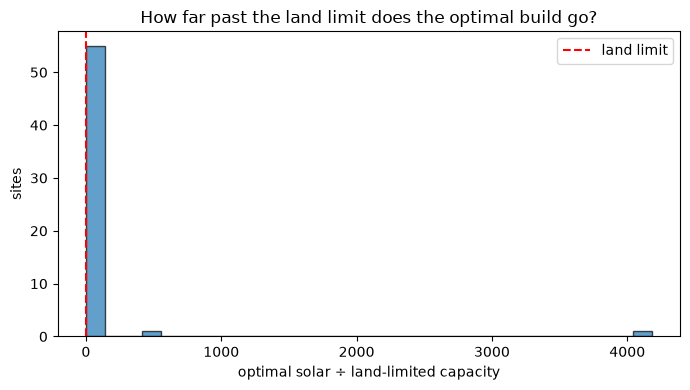

In [7]:
ok["land_ratio"] = ok["S_opt_MW"] / ok["max_solar_land_mw"].replace(0, np.nan)
n_fit = (~ok["exceeds_land_limit"].astype(bool)).sum()
print(f"sites whose optimal solar fits available land: {n_fit} / {len(ok)}")
print(f"land_ratio (optimal solar MW ÷ land-limited MW): median {ok['land_ratio'].median():.2f}, "
      f"max {ok['land_ratio'].max():.1f}")
fits = ok[~ok["exceeds_land_limit"].astype(bool)]
heat_fit = fits["replaceable_heat_mwh_th"].sum() / ok["replaceable_heat_mwh_th"].sum()
print(f"share of steam heat at sites that fit: {heat_fit:.0%}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ok["land_ratio"].dropna(), bins=30, edgecolor="k", alpha=0.7)
ax.axvline(1.0, color="r", ls="--", label="land limit")
ax.set_xlabel("optimal solar ÷ land-limited capacity"); ax.set_ylabel("sites"); ax.legend()
ax.set_title("How far past the land limit does the optimal build go?")
plt.tight_layout(); plt.show()

## 4. Reliability & sizing sanity checks

With VoLL = 0 and a 10% unserved budget, the optimizer treats unserved energy as free — so it will
always use ~the full budget (reliability pinned at ~90%). Reliability here is a **constraint**, not
an outcome (loophole L3). Also check the infeasibility decrement loop never triggered.

In [8]:
print(ok["Reliability_%"].describe().round(2))
print(f"\nsites where feasible_load_mw < load_target_mw: "
      f"{(ok['feasible_load_mw'] < ok['load_target_mw'] - 1e-9).sum()}")
print(f"unserved hours per site: median {ok['Unserved_hours'].median():.0f}, max {ok['Unserved_hours'].max():.0f} "
      f"(of 8760 — a ~10% energy budget concentrates in winter)")
ok["storage_hours"] = ok["Heat_TES_energy_MWh"] / ok["Heat_TES_discharge_power_MW"].replace(0, np.nan)
print(f"TES duration at discharge: median {ok['storage_hours'].median():.1f} h (cap 12 h)")
print(f"solar overbuild (S_opt ÷ load): median {(ok['S_opt_MW']/ok['load_MW']).median():.1f}×")

count    60.0
mean     90.0
std       0.0
min      90.0
25%      90.0
50%      90.0
75%      90.0
max      90.0
Name: Reliability_%, dtype: float64

sites where feasible_load_mw < load_target_mw: 0
unserved hours per site: median 966, max 1111 (of 8760 — a ~10% energy budget concentrates in winter)
TES duration at discharge: median 12.0 h (cap 12 h)
solar overbuild (S_opt ÷ load): median 16.5×


## 5. Back-of-envelope: 2030 TES costs

TES CAPEX falls from \$100/kWh (2025) to \$20/kWh (2030) in `input_heat_battery_cost.csv`.
The TES LCOH component scales ~linearly with energy CAPEX **at fixed sizing**; re-optimizing would
do better (cheaper storage → less curtailed solar), so this is an **upper bound** on 2030 LCOH.

In [9]:
ok["LCOH_2030_approx"] = ok["LCOE_solar_$perMWh"] + ok["LCOE_TES_$perMWh"] * (20 / 100)
print(ok[["LCOE_total_$perMWh", "LCOH_2030_approx"]].describe().round(0))
print("\nNote: upper bound — re-optimization with cheap storage would lower this further.")

       LCOE_total_$perMWh  LCOH_2030_approx
count                60.0              60.0
mean                200.0             155.0
std                 175.0             145.0
min                  48.0              31.0
25%                  84.0              61.0
50%                 124.0              88.0
75%                 252.0             205.0
max                 709.0             579.0

Note: upper bound — re-optimization with cheap storage would lower this further.


## 6. Loopholes / items to verify

**L1 — stale outputs in `summary.csv`.** `_build_summary` merges every `site_*.csv` on disk. If the
site filter changes between runs, old files persist and mix assumptions. Checked in §1 via the
`steam_temp_c` column; safest practice is to clear `output/sites/` before a full re-run.

**L2 — land is a flag, not a constraint.** The LP can build unlimited solar; `exceeds_land_limit`
only compares after the fact. Sites flagged infeasible-on-land might still work with a
land-constrained (more storage-heavy, costlier) design — worth adding `S_MW ≤ land_mw` as an LP
bound in a follow-up run before claiming a site is infeasible.

**L3 — reliability is pinned by construction.** VoLL = 0 + a 10% unserved budget means every site
reports ~90% reliability; the model answers "cost of serving 90% of a flat load", not "how reliable
is the system". The remaining 10% implicitly stays on the fossil boiler — the headline claim should
say *"solar + IHB can replace ~90% of fossil steam"*, and the LCOH excludes any cost for that backup.

**L4 — flat load profile.** Real mills vary within-day and seasonally; a flat profile likely
understates winter storage needs and overstates summer needs. Direction of LCOH bias is ambiguous.

**L5 — inverter efficiency on the heat path.** The solver's AC-bus balance multiplies TES
*discharge* by inverter efficiency (0.967), but a heat battery discharges heat directly — no
inverter. Similarly, direct solar→load bypasses the electric-to-heat efficiency (0.98). Both are
~2–3% effects, partially offsetting, but the bus accounting deserves a review pass.

**L6 — single solar year (2023).** No interannual variability; a poor solar winter would need more
storage than sized here.

**L7 — steam scope caveat.** Lime-kiln fuel (~900 °C, ~8–12% of kraft-mill fuel input) is excluded
by scope statement, not subtracted from the load. Where country-average fossil shares include kiln
fuel, addressable steam demand at fossil-fired kraft (Pulp/Integrated) sites is overstated by
roughly the kiln's slice of *fossil* fuel — which can exceed 8–12% where boilers burn biomass.
Conversely, Nordic kilns often already burn biomass (already excluded via low fossil shares).

**L8 — sector-average intensities and country-average fossil shares.** `SEC` and `fossil_share`
are classification/country averages, not site data; site-level heat demand can be off substantially.

**L9 — unserved budget is annual energy, not hourly.** Nothing prevents long continuous winter
outages; a mill needs its ~10% backup to be dispatchable for days at a time.

**L10 — TES CAPEX year.** TES CAPEX falls 5× from 2025 (\$100/kWh) to 2030 (\$20/kWh) in the
cost file; §5 approximates the effect. Run the 2030 scenario before drawing final feasibility
conclusions.

**L11 — units discipline in cost inputs.** The corrected discount-rate bug (see header) shows how
sensitive the pipeline is to unit conventions in `input_heat_battery_cost.csv` (percent vs
fraction, \$/kWh vs \$/MWh). Any new row added to that file should state units in the `Units`
column and be sanity-checked against a hand calculation (e.g. CRF at 7%/25 yr ≈ 0.0858, so
\$100/kWh ⇒ ≈ \$10.6/kWh-yr ≈ \$10,600/MWh-yr annualized).

## Reproduce

```bash
python run_ihb_potential.py --no-resume          # from the project root
# then re-run this notebook (it reads flatblock_optimization/output/summary.csv)
```